In [1]:
#import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import joblib

In [2]:


DATA_PATH = Path("../data/raw/dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset introuvable. Consultez le README pour le télécharger."
    )

df = pd.read_csv(DATA_PATH)

In [3]:
#Présentation du dataset
print(df.shape)
print(df.info())
print(df.describe())
print(df.head())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
#Vérification des doublons
df.duplicated().sum()


np.int64(0)

In [5]:
# Vérification des valeurs manquantes
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Analyse de la variable cible
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
# Traitement des valeurs manquantes dans la colonne "TotalCharges"
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [8]:
# Remplacer les valeurs manquantes par la médiane de la colonne
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\lea\AppData\Local\Temp\ipykernel_19060\2104995638.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [9]:
# Encodage de la variable cible "Churn"
le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

In [10]:
# Analyse des variables catégorielles
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print(df[col].value_counts())

customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes               

<Axes: xlabel='Churn', ylabel='count'>

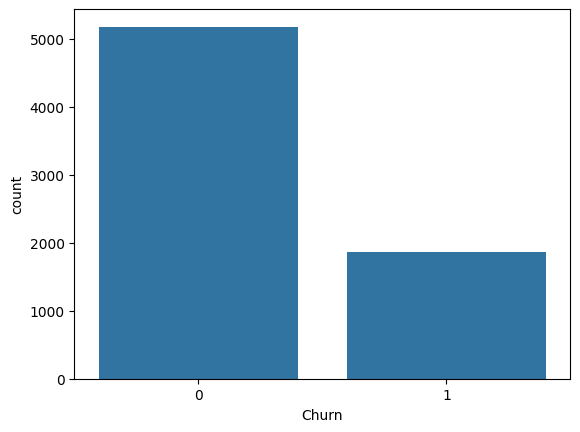

In [11]:
# Analyse des variables
df["Churn"].value_counts(normalize=True)
sns.countplot(data=df, x="Churn")

<Axes: xlabel='MonthlyCharges'>

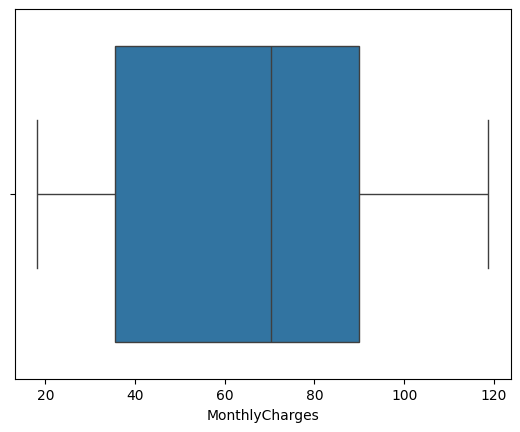

In [12]:
# Analyse des variables numériques
sns.boxplot(x=df["MonthlyCharges"])
#sns.boxplot(x=df["TotalCharges"])

In [13]:
# Methode interquartile pour détecter les outliers
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["MonthlyCharges"] < lower)
    | (df["MonthlyCharges"] > upper)
]

len(outliers)



0

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

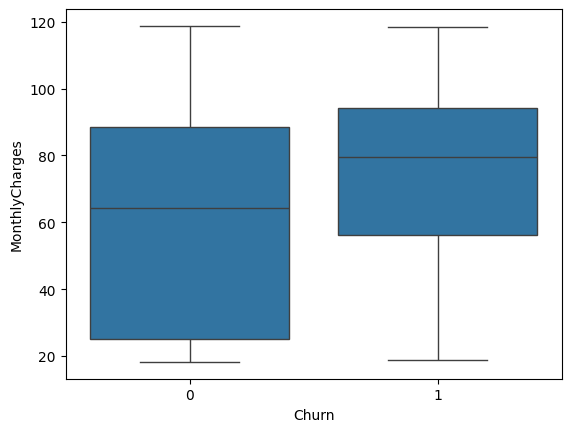

In [14]:
# etude de la relation entre "Churn" et "MonthlyCharges"
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

<Axes: xlabel='Contract', ylabel='count'>

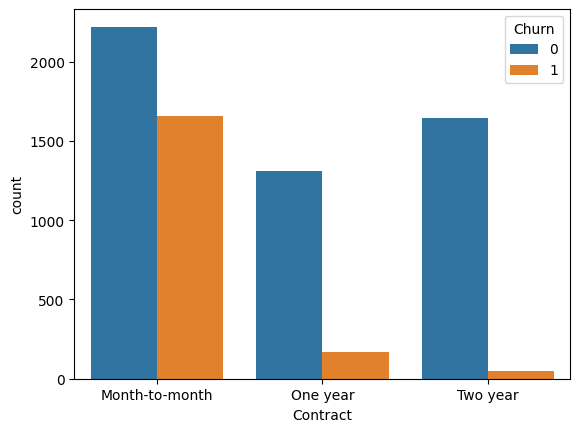

In [15]:
# etude des churns selon le contrats
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

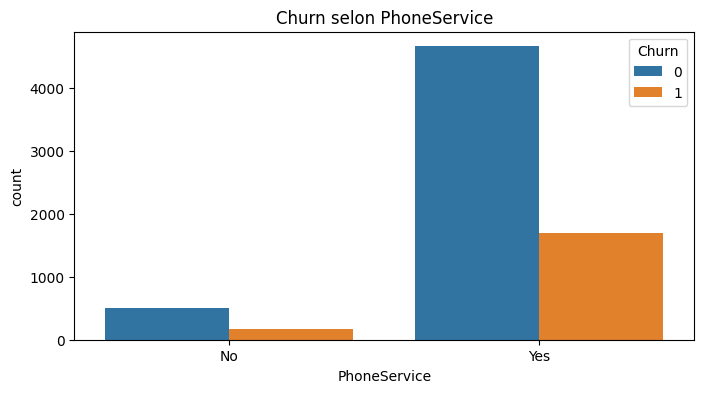

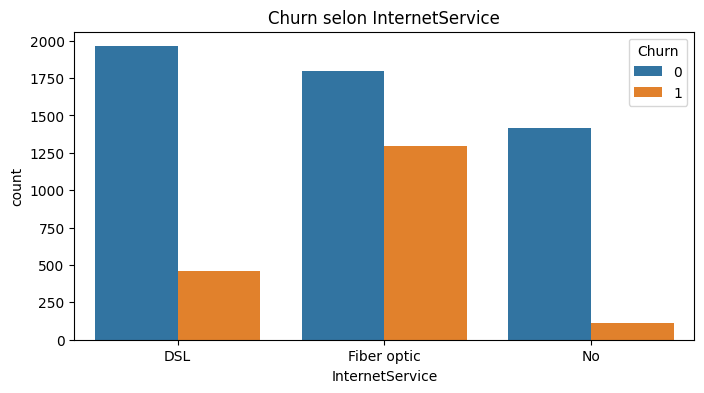

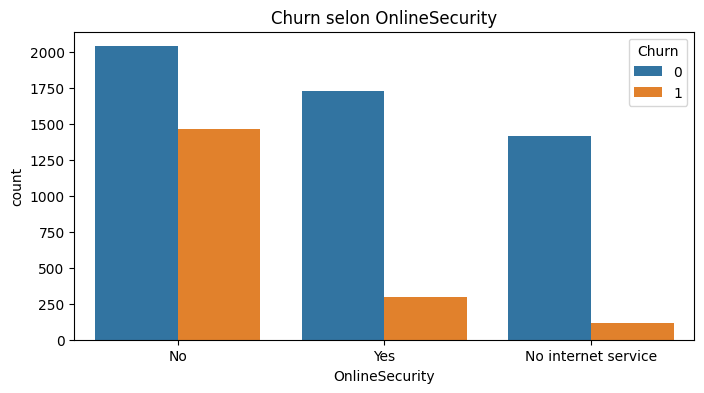

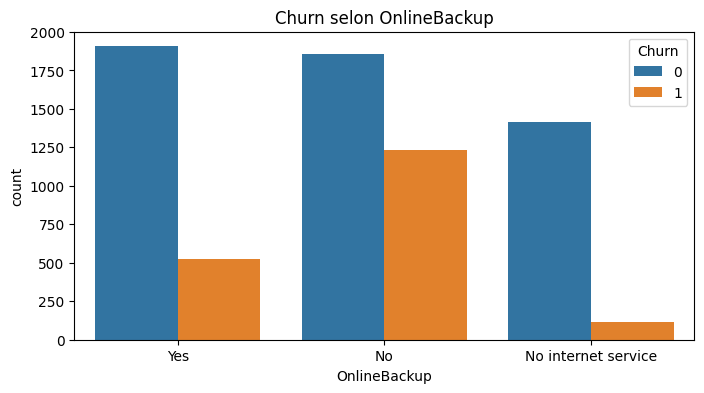

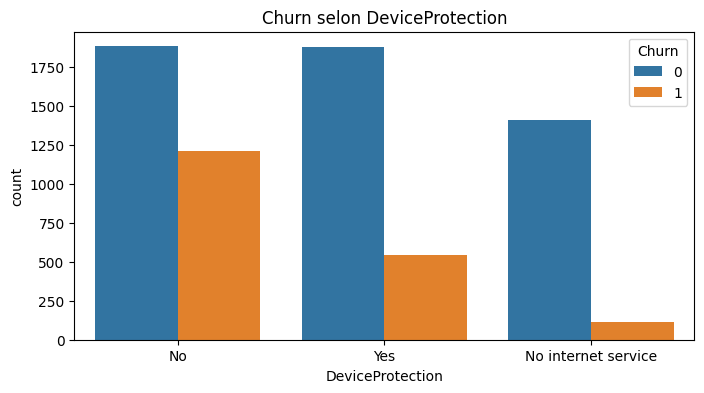

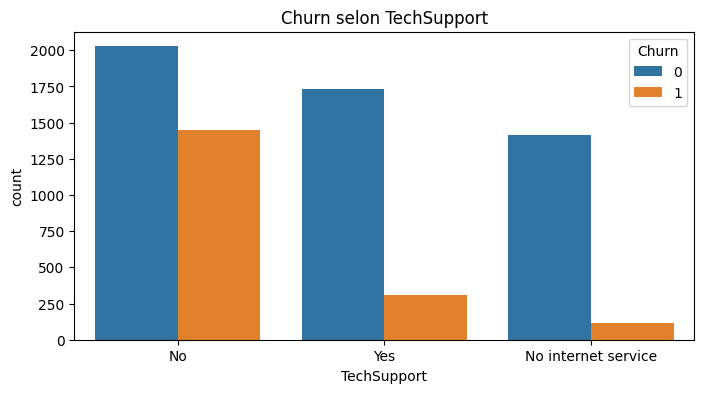

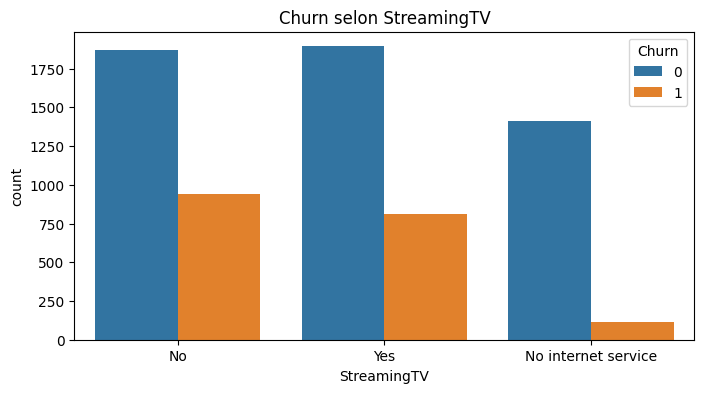

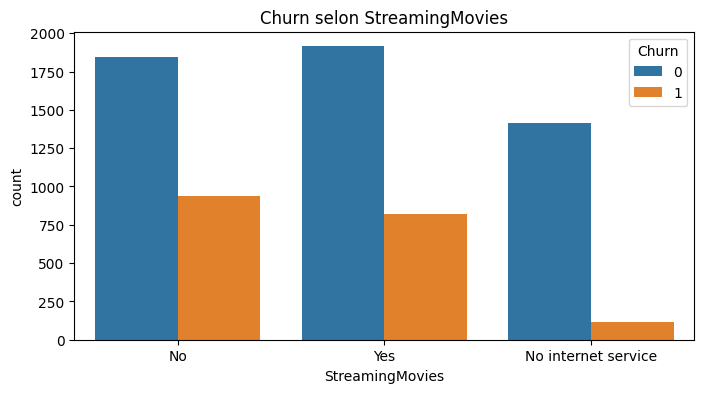

In [16]:
# etudes des churns selon les services
services = ["PhoneService", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"] 
for service in services:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=service,
        hue="Churn"
    )
    plt.title(f"Churn selon {service}")
    plt.show()

<Axes: xlabel='PaymentMethod', ylabel='count'>

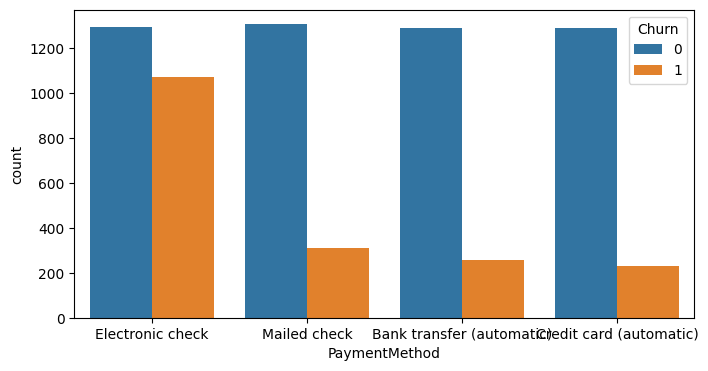

In [17]:
# Etudes des churns selon les méthodes de paiement
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

<Axes: xlabel='Churn', ylabel='tenure'>

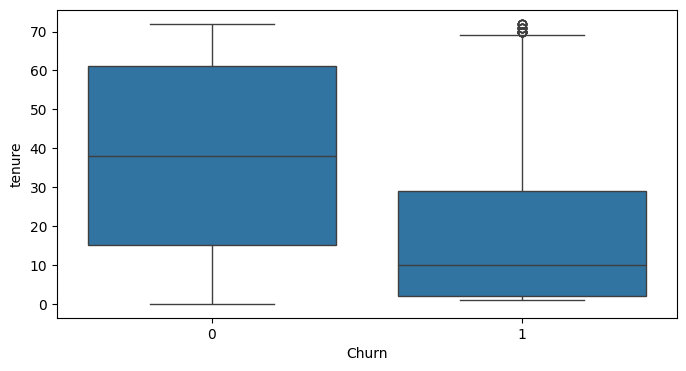

In [18]:
# etude des churn selon l'ancienneté
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

In [19]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [20]:

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_cols = [
    col for col in df.columns
    if col not in num_cols + ["customerID", "Churn"]
]

print(num_cols)
print(cat_cols)



['tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


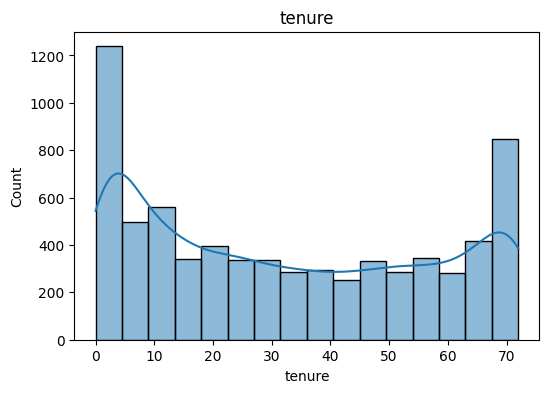

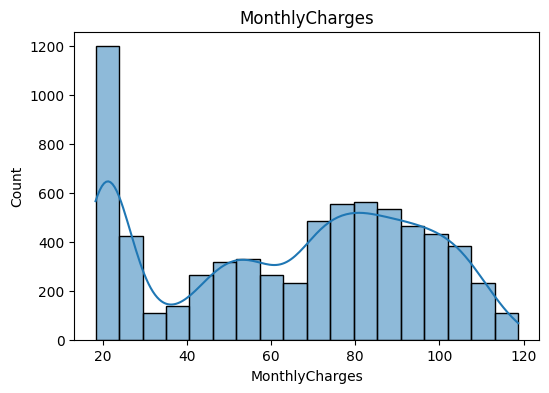

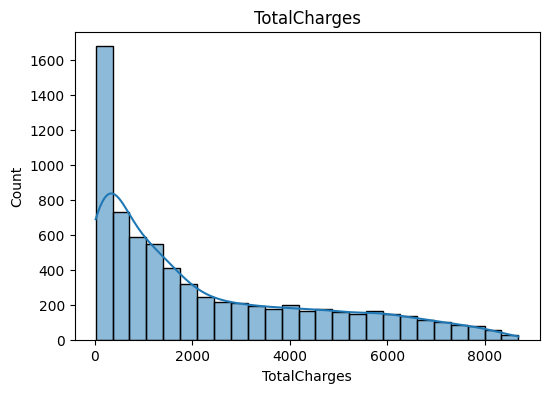

In [21]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()



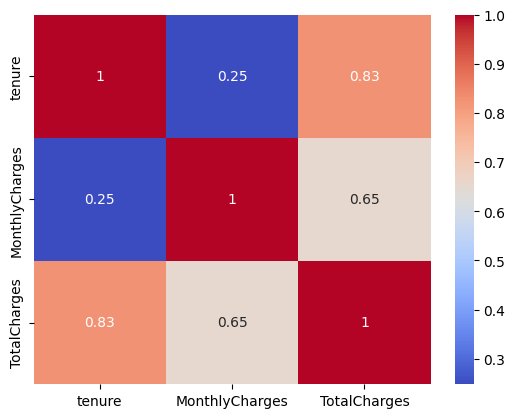

In [22]:


df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)



num_cols = ["tenure","MonthlyCharges","TotalCharges"]

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()



In [23]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

ohe_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
        "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

encoder = ColumnTransformer(
    transformers=[
        ("binary", OneHotEncoder(drop="if_binary"), binary_cols),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ohe_cols)
    ],
    remainder="passthrough"
)

In [24]:
X = df.drop("Churn", axis=1)
X = X.drop("customerID", axis=1)
y = df["Churn"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    stratify=y_train_val,
    random_state=42
)

encoder = ColumnTransformer(
    transformers=[
        ("binary", OneHotEncoder(drop="if_binary"), binary_cols),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ohe_cols)
    ],
    remainder="passthrough"
)




In [25]:
encoder.fit(X_train)
X_train_encoded = encoder.transform(X_train)
X_val_encoded = encoder.transform(X_val)
X_test_encoded = encoder.transform(X_test)

In [26]:
print(X_train_encoded.shape)
print(X_val_encoded.shape)
print(X_test_encoded.shape)

(4929, 40)
(1057, 40)
(1057, 40)


In [27]:
# Normalisation
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

# Évaluation
y_pred = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("Précision:", mlp.score(X_test_scaled, y_test))
print("Précision sur le set de validation:", mlp.score(X_val_scaled, y_val))
print("Précision sur le set d'entraînement:", mlp.score(X_train_scaled, y_train))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       777
           1       0.52      0.54      0.53       280

    accuracy                           0.75      1057
   macro avg       0.68      0.68      0.68      1057
weighted avg       0.75      0.75      0.75      1057

Précision: 0.7483443708609272
Précision sur le set de validation: 0.7634815515610217
Précision sur le set d'entraînement: 0.9184418746195983
0.7483443708609272
[[640 137]
 [129 151]]


C:\Users\lea\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [28]:
joblib.dump(encoder, "../models/encoder.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(mlp, "../models/mlp.pkl")

['../models/mlp.pkl']

In [29]:
# baseline model
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(random_state=42)
baseline.fit(X_train_scaled, y_train)
y_pred = baseline.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       777
           1       0.66      0.57      0.61       280

    accuracy                           0.81      1057
   macro avg       0.75      0.73      0.74      1057
weighted avg       0.80      0.81      0.80      1057

Accuracy : 0.8070009460737938
[[694  83]
 [121 159]]


In [30]:
# Rigde L2
from sklearn.linear_model import RidgeClassifier
ridge = RidgeClassifier(random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print(classification_report(y_test, y_pred_ridge))
print("Accuracy :", accuracy_score(y_test, y_pred_ridge))
print(confusion_matrix(y_test, y_pred_ridge))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87       777
           1       0.65      0.55      0.59       280

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.79      1057

Accuracy : 0.8003784295175024
[[693  84]
 [127 153]]


In [31]:
# Logistic Regression avec régularisation L2
ridge2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    max_iter=500
)

ridge2.fit(X_train_scaled, y_train)

ridge2_pred = ridge2.predict(X_test_scaled)

print("Accuracy Ridge2 :", accuracy_score(y_test, ridge2_pred))
print('confusion_matrix Ridge2 :\n', confusion_matrix(y_test, ridge2_pred))

Accuracy Ridge2 : 0.8070009460737938
confusion_matrix Ridge2 :
 [[694  83]
 [121 159]]


In [32]:
# Lasso L1
lasso = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=500
)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("Accuracy Lasso :", accuracy_score(y_test, lasso_pred))
print('confusion_matrix Lasso :\n', confusion_matrix(y_test, lasso_pred))

Accuracy Lasso : 0.8070009460737938
confusion_matrix Lasso :
 [[693  84]
 [120 160]]


In [33]:
# ElasticNet L1 et L2
elasticnet = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.5,
    C=1.0,
    solver='saga',
    max_iter=500
)
elasticnet.fit(X_train_scaled, y_train)
elasticnet_pred = elasticnet.predict(X_test_scaled)
print("Accuracy ElasticNet :", accuracy_score(y_test, elasticnet_pred))
print('confusion_matrix ElasticNet :\n', confusion_matrix(y_test, elasticnet_pred))

Accuracy ElasticNet : 0.8079470198675497
confusion_matrix ElasticNet :
 [[694  83]
 [120 160]]


C:\Users\lea\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [34]:
# Entraînement d'un modèle de Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print("Accuracy Random Forest :", accuracy_score(y_test, rf_pred))
print('confusion_matrix Random Forest :\n', confusion_matrix(y_test, rf_pred))

Accuracy Random Forest : 0.7805108798486282
confusion_matrix Random Forest :
 [[686  91]
 [141 139]]


In [35]:
# Comparaison des modèles
models = {
    "Baseline Logistic Regression": (baseline, y_pred),
    "Ridge L2": (ridge, y_pred_ridge),
    "Logistic Regression L2": (ridge2, ridge2_pred),
    "Lasso L1": (lasso, lasso_pred),
    "ElasticNet": (elasticnet, elasticnet_pred),
    "Random Forest": (rf, rf_pred)
}


In [36]:
results = pd.DataFrame({
    "Modèle": ["Baseline", "Ridge", "Lasso", "ElasticNet", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, baseline.predict(X_test_scaled)),
        accuracy_score(y_test, ridge.predict(X_test_scaled)),
        accuracy_score(y_test, lasso.predict(X_test_scaled)),
        accuracy_score(y_test, elasticnet.predict(X_test_scaled)),
        accuracy_score(y_test, rf.predict(X_test_scaled))
    ]
})

print(results)


          Modèle  Accuracy
0       Baseline  0.807001
1          Ridge  0.800378
2          Lasso  0.807001
3     ElasticNet  0.807947
4  Random Forest  0.780511


Le meilleur modèle est le ElasticNet 

In [37]:
# Enregistrement des modèles
joblib.dump(encoder, "../models/encoder.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(mlp, "../models/mlp.pkl")
joblib.dump(baseline, "../models/baseline.pkl")
joblib.dump(ridge, "../models/ridge.pkl")
joblib.dump(ridge2, "../models/ridge2.pkl")
joblib.dump(lasso, "../models/lasso.pkl")
joblib.dump(elasticnet, "../models/elasticnet.pkl")
joblib.dump(rf, "../models/random_forest.pkl")



['../models/random_forest.pkl']

In [38]:
# Courbe d'apprentissa

NameError: name 'train_sizes' is not defined

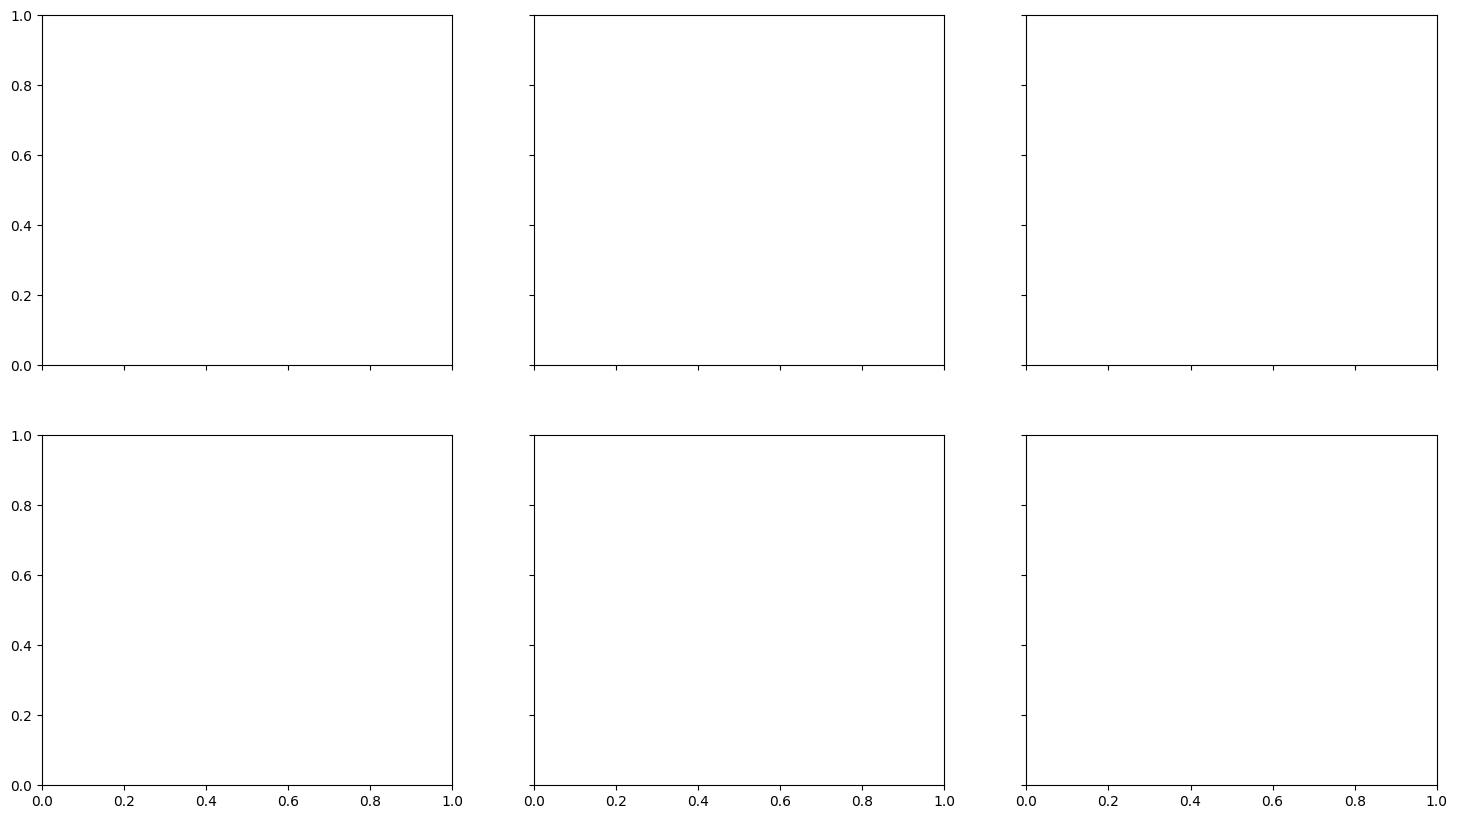

In [39]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, (estimator, _)) in zip(axes, models.items()):
    train_sizes_l, train_scores_l, test_scores_l = learning_curve(
        estimator,
        X_train_scaled,
        y_train,
        cv=5,
        train_sizes=train_sizes,
        scoring="accuracy",
        n_jobs=-1
    )
    train_mean = train_scores_l.mean(axis=1)
    test_mean = test_scores_l.mean(axis=1)
    train_std = train_scores_l.std(axis=1)
    test_std = test_scores_l.std(axis=1)

    ax.plot(train_sizes_l, train_mean, marker="o", label="Train")
    ax.plot(train_sizes_l, test_mean, marker="o", label="Validation")
    ax.fill_between(train_sizes_l, train_mean - train_std, train_mean + train_std, alpha=0.1)
    ax.fill_between(train_sizes_l, test_mean - test_std, test_mean + test_std, alpha=0.1)
    ax.set_title(name)
    ax.set_xlabel("Train size")
    ax.set_ylabel("Accuracy")
    ax.grid(True)
    ax.legend(fontsize="small")

plt.tight_layout()
plt.show()